# Challenge 16

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Inference: I think that as the step size increases, both the global error and the local truncation error will increase. This is because Euler’s method approximates using straight-line segments, and larger step sizes result in fewer, but longer segments that will not capture the curvature of the curve very well. Therefore, I think that smaller step sizes will create more accurate approximations, while larger step sizes will result in greater deviations from the exact solution curve.


 Step Size:  0.1

 Global Error [0.         0.01873075 0.03032005 0.03681164 0.03972896 0.04019944
 0.03905021 0.03688176 0.03412436 0.03108116 0.0279611  0.02490381
 0.02199848 0.019298   0.0168296  0.0146027  0.01261471 0.01085527
 0.00930932 0.00795925 0.00678642]

 Local Error [0.01873075 0.01533544 0.0125556  0.01027966 0.00841627 0.00689066
 0.00564159 0.00461895 0.00378167 0.00309617 0.00253493 0.00207543
 0.00169922 0.0013912  0.00113902 0.00093255 0.00076351 0.00062511
 0.00051179 0.00041902]

 Total Error 0.4800469939772947

 Step Size:  0.5

 Global Error [0.         0.36787944 0.13533528 0.04978707 0.01831564]

 Local Error [0.36787944 0.13533528 0.04978707 0.01831564]

 Total Error 0.5713174316646532

 Step Size:  1

 Global Error [0.         1.13533528 0.98168436]

 Local Error [1.13533528 0.15365092]

 Total Error 2.1170196443478786

 Step Size:  1.5

 Global Error [0.         2.04978707]

 Local Error [2.04978707]

 Total Error 2.049787068367864


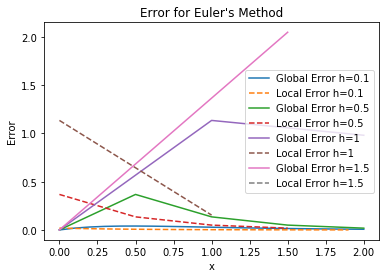

In [2]:
h_vals = [.1, .5, 1, 1.5]

first_y = None
first_x = None

# exact solution
def y_exact(x):
    return np.exp(-2*x)


for h in h_vals:
        
    x_start, x_end = 0, 2
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_start + h*num_steps, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    # Initial condition
    y_values[0] = 1  # y(0) = 1
    
    # Function representing dy/dx = -2y
    def f(x, y):
        return -2 * y

    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
    
    # storing the first run as a reference
    if first_y is None:
        first_y = y_values.copy()
        first_x = x_values.copy()

    # error(current run vs first run)
    first_interp = np.interp(x_values, first_x, first_y)

    # GLOBAL ERROR (vs exact solution)
 
    exact_vals = y_exact(x_values)
    global_err = np.abs(y_values - exact_vals)


    #local error
    local_err = np.abs(y_exact(x_values[:-1]) + h * f(x_values[:-1], y_exact(x_values[:-1])) - y_exact(x_values[1:]))

    tot_err = np.sum(global_err)
    
    # Printing the results (Current step size, Error for each point, and the total error)
    print("\n Step Size: ", round(h,3))
    print("\n Global Error", global_err)
    print("\n Local Error", local_err)
    print("\n Total Error", tot_err)
    
    # Plotting the results
    plt.plot(x_values, global_err, label=f"Global Error h={h}")
    plt.plot(x_values[:-1], local_err, '--', label=f"Local Error h={h}")

    
plt.xlabel('x')
plt.ylabel('Error')
plt.title("Error for Euler's Method")
plt.legend()
plt.show()

Conclusion: The results confirm my initial inference, as when the step size increased, both the errors increased. The graph shows that smaller step sizes result in solutions that are more similar to the exact solution, while the larger step sizes lead to greater errors. This shows that Euler’s method becomes less acurate as the step size increases and confirms that the method is very delicate to step size, when it approximates curved graphs.